# 📑 Notebook – Inteligência Artificial: Model LifeCycle | Breast Cancer Dataset

## Importando as Bibliotecas Necessárias

In [57]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression


## 1. Carregamento e Pré-Processamento dos Dados

In [58]:

dados = load_breast_cancer()
df = pd.DataFrame(data=dados.data, columns=dados.feature_names)
df['target'] = dados.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Definindo as Features e Variáveis-Alvo

In [59]:

X = df.drop(['target'], axis=1)
y = df['target']

escalonador = StandardScaler()
X_normalizado = escalonador.fit_transform(X)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_normalizado, y, test_size=0.3, random_state=42
)


## 3. Treinamento e Avaliação Inicial do Modelo KNN

In [60]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_treino, y_treino)

y_pred = knn.predict(X_teste)

acuracia = accuracy_score(y_teste, y_pred)
print(f'Acurácia: {acuracia:.4f}')


Acurácia: 0.9591


## 4. Matriz de Confusão

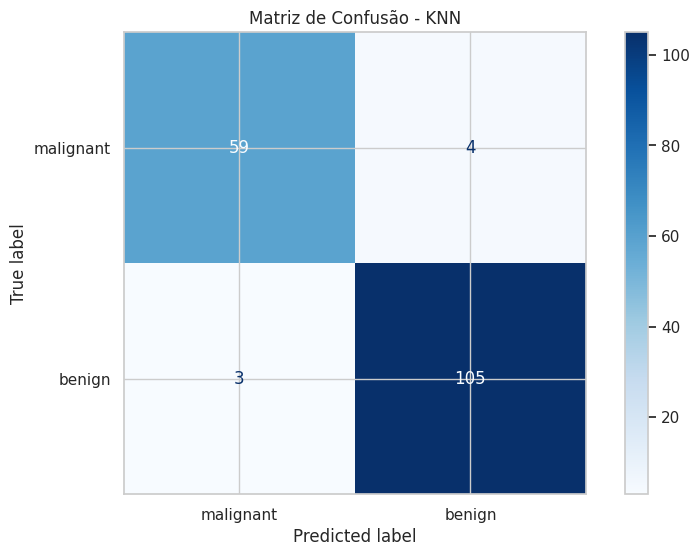

In [61]:

cm = confusion_matrix(y_teste, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dados.target_names)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - KNN')
plt.show()


## 5. Análise da Performance Variando o K

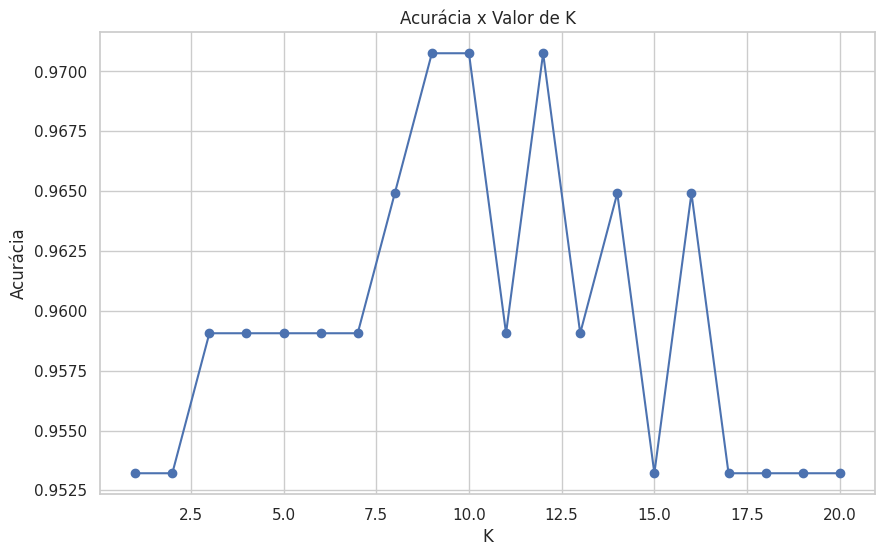

Melhor K: 9 com Acurácia: 0.9708


In [62]:

k_range = range(1, 21)
scores = []

for k in k_range:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_treino, y_treino)
    y_pred_k = modelo.predict(X_teste)
    scores.append(accuracy_score(y_teste, y_pred_k))

plt.plot(k_range, scores, marker='o')
plt.title('Acurácia x Valor de K')
plt.xlabel('K')
plt.ylabel('Acurácia')
plt.grid(True)
plt.show()

melhor_k = k_range[np.argmax(scores)]
melhor_acuracia = max(scores)
print(f'Melhor K: {melhor_k} com Acurácia: {melhor_acuracia:.4f}')


## 6. Geração de Dados Sintéticos com Ruído

In [63]:

qtd_sinteticos = int(0.3 * X_treino.shape[0])
indices = np.random.choice(X_treino.shape[0], qtd_sinteticos, replace=True)
X_sintetico = X_treino[indices]
y_sintetico = y_treino.values[indices]

np.random.seed(42)
ruido = np.random.normal(0, 0.2, X_sintetico.shape)
X_sintetico += ruido

X_treino_aug = np.vstack([X_treino, X_sintetico])
y_treino_aug = np.hstack([y_treino, y_sintetico])

modelo_knn_aug = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn_aug.fit(X_treino_aug, y_treino_aug)

y_pred_aug = modelo_knn_aug.predict(X_teste)
acuracia_aug = accuracy_score(y_teste, y_pred_aug)

print(f"Acurácia com dados aumentados: {acuracia_aug:.4f}")


Acurácia com dados aumentados: 0.9591


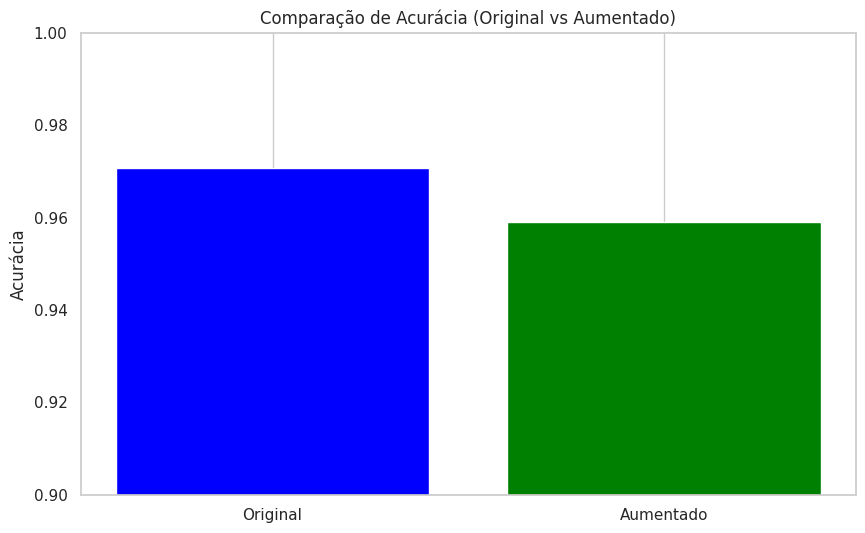

In [64]:

plt.bar(['Original', 'Aumentado'], [melhor_acuracia, acuracia_aug], color=['blue', 'green'])
plt.title('Comparação de Acurácia (Original vs Aumentado)')
plt.ylabel('Acurácia')
plt.ylim(0.9, 1.0)
plt.grid(axis='y')
plt.show()


## 7. Modelo de Regressão Linear – Previsão da Área Média do Tumor

In [65]:

y_reg = df['mean area']
X_reg = df.drop(['mean area', 'target'], axis=1)

X_reg_normalizado = escalonador.fit_transform(X_reg)

Xr_treino, Xr_teste, yr_treino, yr_teste = train_test_split(
    X_reg_normalizado, y_reg, test_size=0.3, random_state=42
)


In [66]:

modelo_reg = LinearRegression()
modelo_reg.fit(Xr_treino, yr_treino)

yr_pred = modelo_reg.predict(Xr_teste)

r2 = r2_score(yr_teste, yr_pred)
mae = mean_absolute_error(yr_teste, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_teste, yr_pred))

print(f'R²: {r2:.4f}')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')


R²: 0.9960
MAE: 13.82
RMSE: 21.11


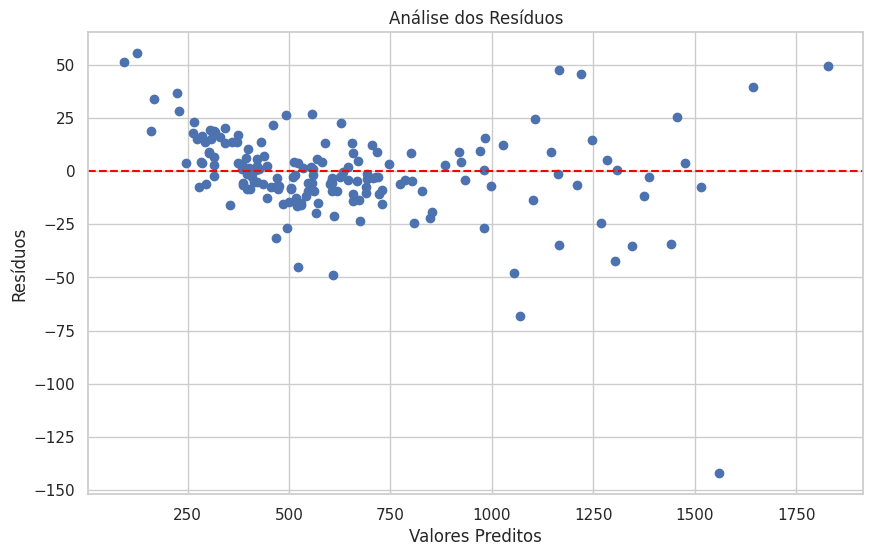

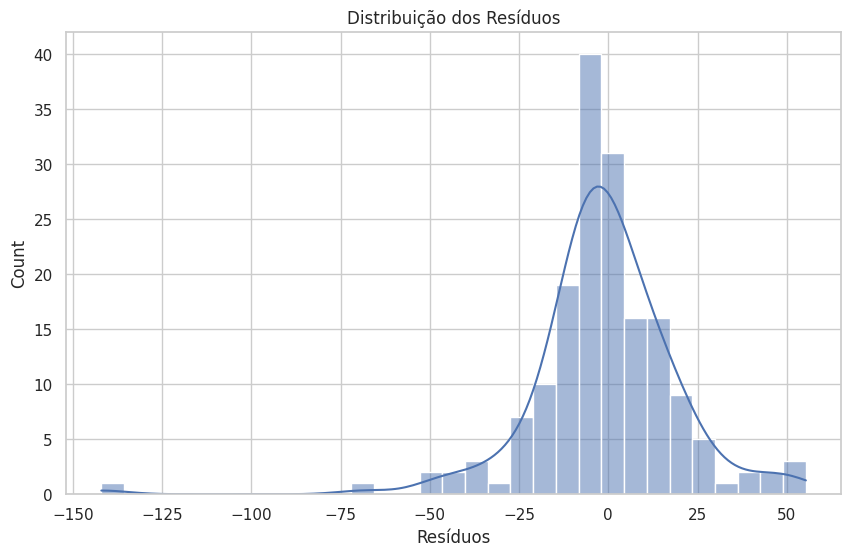

In [67]:

residuos = yr_teste - yr_pred

plt.scatter(yr_pred, residuos)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Análise dos Resíduos')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.grid(True)
plt.show()

sns.histplot(residuos, kde=True)
plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduos')
plt.show()
